# 定增项目情景分析

## 📌 分析内容

本 Notebook 分析定增项目在不同情景下的风险表现：
- 发行价折扣情景分析（折价 vs 溢价）
- 不同时间窗口风险指标对比
- 破发概率情景分析

---

## 情景分析 vs 敏感性分析

**情景分析**（本 Notebook）：
- 对比多个变量的不同组合情景
- 评估不同市场环境下的风险收益
- 示例：不同时间窗口下的风险对比

**敏感性分析**（见 [01_1_sensitivity_analysis.ipynb](01_1_sensitivity_analysis.ipynb)）：
- 单一参数变化对结果的影响
- 识别关键风险因素
- 示例：波动率变化对盈利概率的影响

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.analysis_tools import PrivatePlacementRiskAnalyzer
from datetime import datetime

# 直接配置中文字体
from utils.direct_font_config import setup
setup()

# 获取字体属性
from utils.font_manager import get_font_prop
font_prop = get_font_prop()

%matplotlib inline
sns.set_style('whitegrid')

print('✅ 库导入成功')

✅ 使用字体: Heiti TC
   路径: /System/Library/Fonts/STHeiti Medium.ttc
✅ 使用系统字体: /System/Library/Fonts/STHeiti Medium.ttc
✅ 库导入成功


## 1. 加载配置

In [2]:
from utils.config_loader import load_placement_config, print_config_summary

print("正在加载配置...")
project_params, risk_params, market_data = load_placement_config('300735.SZ')

print_config_summary(project_params, risk_params, market_data)

# 创建分析器
analyzer = PrivatePlacementRiskAnalyzer(**project_params)

正在加载配置...
✅ 已加载定增参数: ../data/300735_SZ_placement_params.json
✅ 已加载市场数据: ../data/300735_SZ_market_data.json
   股票: 光弘科技 (300735.SZ)
   分析日期: 20260306
   当前价格: 23.88 元
✅ 使用市场数据中的最新价格: 23.88 元
✅ 使用真实市场数据:
   波动率: 30.63% (60日)
   收益率: -18.75% (60日年化)

📊 定增分析配置

📋 项目参数:
   发行价格: 20.25 元/股
   当前价格: 23.88 元/股
   锁定期: 6 个月
   发行数量: 5,000,000 股
   融资金额: 1.01 亿元
   当前收益率: +17.95% （浮盈）

📌 发行类型判断:
   MA30: 25.31 元
   发行价: 20.25 元
   ✅ 折价发行（有安全边际）
   安全边际: 20.01%

⚠️ 风险参数:
   波动率: 30.63%
   收益率(漂移率): -18.75%
   数据来源: market_data

📈 波动率详情:
   30日: 33.96%
   60日: 30.63%
   120日: 37.13%
   180日: 36.60%


## 2. 发行价折扣情景分析

### 核心逻辑

**发行类型定义**：
- **折价发行**：`issue_price < MA20` → 有安全边际，投资风险较低
- **溢价发行**：`issue_price > MA20` → 无安全边际，投资风险较高

**盈利阈值设定**：
- **折价发行**：盈利阈值 = 发行价（已有安全边际，只需不破发）
- **溢价发行**：盈利阈值 = max(MA20, 发行价×1.02)（需回到合理估值或至少2%收益）

In [3]:
# 使用MA30作为MA20的近似
ma20 = market_data['ma_30']

# 判断发行类型
is_discount = project_params['issue_price'] < ma20
issue_type = "折价发行" if is_discount else "溢价发行"

# 计算盈利阈值和安全边际/溢价
if is_discount:
    threshold = project_params['issue_price']
    safety_margin = (ma20 - project_params['issue_price']) / ma20 * 100
    print(f"✅ 发行类型: 折价发行（有安全边际）")
    print(f"   MA30价格: {ma20:.2f} 元")
    print(f"   发行价格: {project_params['issue_price']:.2f} 元")
    print(f"   安全边际: {safety_margin:.2f}%")
    print(f"   盈利阈值: {threshold:.2f} 元（发行价）")
else:
    threshold = max(ma20, project_params['issue_price'] * 1.02)
    premium_rate = (project_params['issue_price'] - ma20) / ma20 * 100
    print(f"⚠️ 发行类型: 溢价发行（无安全边际）")
    print(f"   MA30价格: {ma20:.2f} 元")
    print(f"   发行价格: {project_params['issue_price']:.2f} 元")
    print(f"   溢价幅度: {premium_rate:.2f}%")
    print(f"   盈利阈值: {threshold:.2f} 元（max(MA30, 发行价×1.02)）")

✅ 发行类型: 折价发行（有安全边际）
   MA30价格: 25.31 元
   发行价格: 20.25 元
   安全边际: 20.01%
   盈利阈值: 20.25 元（发行价）


### 不同波动率情景下的盈利概率

In [4]:
print("\n" + "="*60)
print("不同波动率情景下的盈利概率分析")
print("="*60)

volatilities = np.linspace(0.15, 0.60, 10)
drift = risk_params['drift']

prob_analysis = []
for vol in volatilities:
    lockup_vol = vol * np.sqrt(project_params['lockup_period'] / 12)
    lockup_drift = drift * (project_params['lockup_period'] / 12)
    required_return = (threshold - project_params['current_price']) / project_params['current_price']
    
    from scipy.stats import norm
    z_score = (lockup_drift - required_return) / lockup_vol
    profit_prob = 1 - norm.cdf(-z_score)
    loss_prob = 1 - profit_prob
    
    prob_analysis.append({
        'volatility': vol,
        'profit_probability': profit_prob,
        'loss_probability': loss_prob,
        'threshold': threshold
    })

print(f"\n{'波动率':<10} {'盈利阈值':<12} {'盈利概率':<12} {'破发概率':<12}")
print('-'*50)
for _, row in pd.DataFrame(prob_analysis).iterrows():
    if row['volatility'] * 100 % 5 == 0:
        print(f"{int(row['volatility']*100):>3}%      {row['threshold']:>8.2f}元     {row['profit_probability']*100:>7.1f}%      {row['loss_probability']*100:>7.1f}%")

df_prob = pd.DataFrame(prob_analysis)


不同波动率情景下的盈利概率分析

波动率        盈利阈值         盈利概率         破发概率        
--------------------------------------------------
 15%         20.25元        70.9%         29.1%
 20%         20.25元        66.0%         34.0%
 25%         20.25元        63.0%         37.0%
 30%         20.25元        60.9%         39.1%
 35%         20.25元        59.3%         40.7%
 40%         20.25元        58.2%         41.8%
 50%         20.25元        56.6%         43.4%
 60%         20.25元        55.5%         44.5%


In [ ]:
print("\n" + "="*70)
print("不同发行价折扣情景分析")
print("="*70)

# 使用MA30作为基准价格
base_price = ma20

# 定义情景：折价和溢价
scenarios = []
for discount_percent in [-20, -15, -10, -5, 5, 10, 15, 20]:  # 负数=溢价，正数=折价
    issue_price = base_price * (1 - discount_percent/100)
    
    # 判断是折价还是溢价
    if discount_percent > 0:
        scenario_type = "折价发行"
        threshold = issue_price  # 折价发行，盈利阈值为发行价
    else:
        scenario_type = "溢价发行"
        threshold = max(base_price, issue_price * 1.02)  # 溢价发行，盈利阈值为max(MA30, 发行价×1.02)
    
    # 计算盈利概率和预期收益率
    lockup_months = project_params['lockup_period']
    drift = risk_params['drift']
    vol = risk_params['volatility']
    
    lockup_vol = vol * np.sqrt(lockup_months / 12)
    lockup_drift = drift * (lockup_months / 12)
    required_return = (threshold - project_params['current_price']) / project_params['current_price']
    
    from scipy.stats import norm
    z_score = (lockup_drift - required_return) / lockup_vol
    profit_prob = (1 - norm.cdf(-z_score)) * 100
    
    # 预期收益率（假设锁定期后价格回到MA30）
    if discount_percent > 0:
        expected_return = (base_price - issue_price) / issue_price * 100
    else:
        # 溢价情况，需要回到MA30或更高
        expected_return = (base_price - issue_price) / issue_price * 100
    
    scenarios.append({
        '情景类型': scenario_type,
        '折扣率': f"{abs(discount_percent):.0f}%",
        '发行价': f"{issue_price:.2f}",
        '盈利阈值': f"{threshold:.2f}",
        '盈利概率': f"{profit_prob:.1f}%",
        '破发概率': f"{100-profit_prob:.1f}%",
        '预期收益率': f"{expected_return:.1f}%"
    })

df_scenarios = pd.DataFrame(scenarios)

print(f"\n{'情景类型':<10} {'折扣率':<8} {'发行价':<10} {'盈利阈值':<10} {'盈利概率':<10} {'破发概率':<10} {'预期收益率':<12}")
print('-'*80)
for _, row in df_scenarios.iterrows():
    print(f"{row['情景类型']:<10} {row['折扣率']:<8} {row['发行价']:<10} {row['盈利阈值']:<10} "
          f"{row['盈利概率']:<10} {row['破发概率']:<10} {row['预期收益率']:<12}")

# 分离折价和溢价情景
df_discount = df_scenarios[df_scenarios['情景类型'] == '折价发行'].copy()
df_premium = df_scenarios[df_scenarios['情景类型'] == '溢价发行'].copy()

print("\n" + "="*70)
print("情景分析要点：")
print("="*70)
print(f"基准价格(MA30): {base_price:.2f} 元")
print(f"当前价格: {project_params['current_price']:.2f} 元")
print(f"\n折价发行情景：")
for _, row in df_discount.iterrows():
    print(f"  • 折价{row['折扣率']}: 发行价{row['发行价']}元 → 盈利概率{row['盈利概率']}, 预期收益{row['预期收益率']}")

print(f"\n溢价发行情景：")
for _, row in df_premium.iterrows():
    print(f"  • 溢价{row['折扣率']}: 发行价{row['发行价']}元 → 盈利概率{row['盈利概率']}, 预期收益{row['预期收益率']}")

In [ ]:
# 可视化：不同发行价折扣情景分析
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 准备数据
discount_rates = [5, 10, 15, 20]
premium_rates = [5, 10, 15, 20]

# 重新计算数值型数据用于绘图
discount_data = []
premium_data = []

for d in discount_rates:
    issue_price = base_price * (1 - d/100)
    threshold = issue_price
    lockup_vol = risk_params['volatility'] * np.sqrt(project_params['lockup_period'] / 12)
    lockup_drift = risk_params['drift'] * (project_params['lockup_period'] / 12)
    required_return = (threshold - project_params['current_price']) / project_params['current_price']
    z_score = (lockup_drift - required_return) / lockup_vol
    profit_prob = (1 - norm.cdf(-z_score)) * 100
    expected_return = (base_price - issue_price) / issue_price * 100
    discount_data.append({'rate': d, 'profit_prob': profit_prob, 'expected_return': expected_return, 'issue_price': issue_price})

for p in premium_rates:
    issue_price = base_price * (1 + p/100)
    threshold = max(base_price, issue_price * 1.02)
    lockup_vol = risk_params['volatility'] * np.sqrt(project_params['lockup_period'] / 12)
    lockup_drift = risk_params['drift'] * (project_params['lockup_period'] / 12)
    required_return = (threshold - project_params['current_price']) / project_params['current_price']
    z_score = (lockup_drift - required_return) / lockup_vol
    profit_prob = (1 - norm.cdf(-z_score)) * 100
    expected_return = (base_price - issue_price) / issue_price * 100
    premium_data.append({'rate': p, 'profit_prob': profit_prob, 'expected_return': expected_return, 'issue_price': issue_price})

# 1. 折价发行的盈利概率
axes[0, 0].bar([d['rate'] for d in discount_data], [d['profit_prob'] for d in discount_data], 
             color='steelblue', alpha=0.7, label='折价发行')
axes[0, 0].set_xlabel('折价率 (%)', fontproperties=font_prop)
axes[0, 0].set_ylabel('盈利概率 (%)', fontproperties=font_prop)
axes[0, 0].set_title('折价发行 - 盈利概率', fontproperties=font_prop, fontsize=14, fontweight='bold')
for label in axes[0, 0].get_xticklabels():
    label.set_fontproperties(font_prop)
for label in axes[0, 0].get_yticklabels():
    label.set_fontproperties(font_prop)
axes[0, 0].grid(True, alpha=0.3)
for i, d in enumerate(discount_data):
    axes[0, 0].text(d['rate'], d['profit_prob']+1, f"{d['profit_prob']:.1f}%", ha='center', fontsize=10)

# 2. 溢价发行的盈利概率
axes[0, 1].bar([p['rate'] for p in premium_data], [p['profit_prob'] for p in premium_data], 
             color='coral', alpha=0.7, label='溢价发行')
axes[0, 1].set_xlabel('溢价率 (%)', fontproperties=font_prop)
axes[0, 1].set_ylabel('盈利概率 (%)', fontproperties=font_prop)
axes[0, 1].set_title('溢价发行 - 盈利概率', fontproperties=font_prop, fontsize=14, fontweight='bold')
for label in axes[0, 1].get_xticklabels():
    label.set_fontproperties(font_prop)
for label in axes[0, 1].get_yticklabels():
    label.set_fontproperties(font_prop)
axes[0, 1].grid(True, alpha=0.3)
for i, p in enumerate(premium_data):
    axes[0, 1].text(p['rate'], p['profit_prob']+1, f"{p['profit_prob']:.1f}%", ha='center', fontsize=10)

# 3. 预期收益率对比
x_discount = [f"{d['rate']}%" for d in discount_data]
x_premium = [f"{p['rate']}%" for p in premium_data]
y_discount = [d['expected_return'] for d in discount_data]
y_premium = [p['expected_return'] for p in premium_data]

x_pos = np.arange(len(x_discount))
width = 0.35

axes[1, 0].bar(x_pos - width/2, y_discount, width, label='折价发行', color='steelblue', alpha=0.7)
axes[1, 0].bar(x_pos + width/2, y_premium, width, label='溢价发行', color='coral', alpha=0.7)
axes[1, 0].set_xlabel('发行折扣率', fontproperties=font_prop)
axes[1, 0].set_ylabel('预期收益率 (%)', fontproperties=font_prop)
axes[1, 0].set_title('预期收益率对比', fontproperties=font_prop, fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(x_discount)
axes[1, 0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 0].legend(prop=font_prop)
for label in axes[1, 0].get_xticklabels():
    label.set_fontproperties(font_prop)
for label in axes[1, 0].get_yticklabels():
    label.set_fontproperties(font_prop)
axes[1, 0].grid(True, alpha=0.3)

# 4. 发行价对比
y_discount_price = [d['issue_price'] for d in discount_data]
y_premium_price = [p['issue_price'] for p in premium_data]

axes[1, 1].bar(x_pos - width/2, y_discount_price, width, label='折价发行', color='steelblue', alpha=0.7)
axes[1, 1].bar(x_pos + width/2, y_premium_price, width, label='溢价发行', color='coral', alpha=0.7)
axes[1, 1].axhline(y=base_price, color='green', linestyle='--', linewidth=2, label=f'MA30基准 ({base_price:.2f}元)')
axes[1, 1].set_xlabel('发行折扣率', fontproperties=font_prop)
axes[1, 1].set_ylabel('发行价格 (元)', fontproperties=font_prop)
axes[1, 1].set_title('发行价格对比', fontproperties=font_prop, fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(x_discount)
axes[1, 1].legend(prop=font_prop)
for label in axes[1, 1].get_xticklabels():
    label.set_fontproperties(font_prop)
for label in axes[1, 1].get_yticklabels():
    label.set_fontproperties(font_prop)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'不同发行价折扣情景分析 - {market_data["stock_name"]}', 
             fontsize=16, fontweight='bold', fontproperties=font_prop, y=0.995)
plt.tight_layout()
plt.show()

print("\n💡 分析要点：")
print(f"• 折价越多，盈利概率越高，但融资额越少")
print(f"• 溢价越多，盈利概率越低，破发风险越大")
print(f"• 当前实际发行价 {project_params['issue_price']:.2f}元，相对MA30 {(project_params['issue_price']/base_price-1)*100:+.1f}%")

### 不同发行价折扣情景分析

分析不同折价/溢价发行情景下的盈利概率和预期收益率。

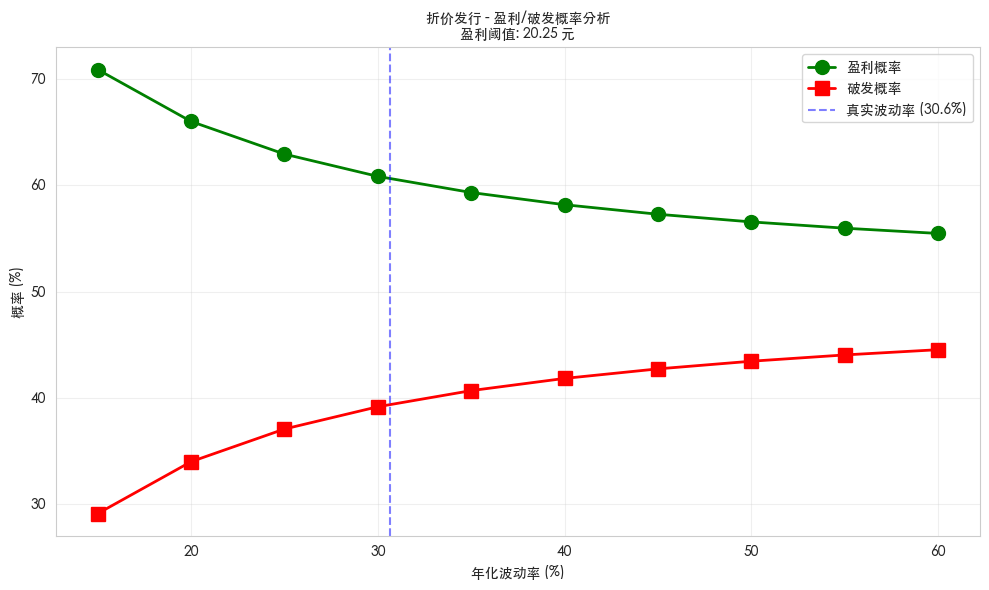

In [5]:
# 可视化
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_prob['volatility']*100, df_prob['profit_probability']*100, 
        'g-o', linewidth=2, markersize=10, label='盈利概率')
ax.plot(df_prob['volatility']*100, df_prob['loss_probability']*100, 
        'r-s', linewidth=2, markersize=10, label='破发概率')

# 添加参考线：真实波动率
real_vol = risk_params['volatility'] * 100
ax.axvline(x=real_vol, color='b', linestyle='--', alpha=0.5, label=f'真实波动率 ({real_vol:.1f}%)')

ax.set_xlabel('年化波动率 (%)', fontproperties=font_prop)
ax.set_ylabel('概率 (%)', fontproperties=font_prop)
title = f'{issue_type} - 盈利/破发概率分析\n'
title += f'盈利阈值: {df_prob["threshold"].iloc[0]:.2f} 元'
ax.set_title(title, fontsize=14, fontweight='bold', fontproperties=font_prop)
ax.legend(prop=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 不同时间窗口风险指标分析

分析不同时间窗口下的风险指标变化：
- 波动率
- 年化收益率
- 最大回撤
- 夏普比率

In [6]:
import tushare as ts
import os
from datetime import timedelta

# 获取历史价格数据
stock_code = '300735.SZ'
end_date = '20260306'

try:
    ts_token = os.environ.get('TUSHARE_TOKEN', '')
    if ts_token:
        pro = ts.pro_api(ts_token)
        
        # 获取最近500个交易日的数据
        start_date = (datetime.strptime(end_date, '%Y%m%d') - timedelta(days=365*2)).strftime('%Y%m%d')
        
        df_price = pro.daily(ts_code=stock_code, start_date=start_date, end_date=end_date)
        
        if not df_price.empty and len(df_price) > 0:
            # 取最近500条数据
            df_price = df_price.tail(500).reset_index(drop=True)
            price_series = df_price['close'].values
            dates = df_price['trade_date'].values
            
            print(f"✅ 获取到 {len(price_series)} 个交易日的数据")
            print(f"   最新价格: {price_series[-1]:.2f} 元")
            print(f"   起始日期: {dates[0]}")
            print(f"   截止日期: {dates[-1]}")
        else:
            print("⚠️ 未获取到数据，将使用市场数据文件中的价格")
            price_series = None
    else:
        print("⚠️ 未设置TUSHARE_TOKEN，将使用市场数据文件")
        price_series = None
except Exception as e:
    print(f"⚠️ 获取数据失败: {e}")
    print("   将跳过时间窗口分析")
    price_series = None

✅ 获取到 484 个交易日的数据
   最新价格: 27.18 元
   起始日期: 20260306
   截止日期: 20240306


In [ ]:
print("\n" + "="*70)
print("多维度情景分析：波动率 × 折价率 × 时间窗口")
print("="*70)

# 定义情景参数
volatility_scenarios = [0.20, 0.30, 0.40, 0.50]  # 低、中、高、极高波动率
discount_scenarios = [-10, -5, 0, 5, 10, 15, 20]  # 溢价10%/5%，平价，折价5%/10%/15%/20%
window_scenarios = [60, 120, 180]  # 不同时间窗口（日）

print(f"\n参数设置：")
print(f"  波动率情景: {len(volatility_scenarios)}个 ({min(volatility_scenarios)*100:.0f}% ~ {max(volatility_scenarios)*100:.0f}%)")
print(f"  折价率情景: {len(discount_scenarios)}个 (溢价{abs(min(discount_scenarios))}% ~ 折价{max(discount_scenarios)}%)")
print(f"  时间窗口: {len(window_scenarios)}个 ({min(window_scenarios)} ~ {max(window_scenarios)}日)")
print(f"  总情景数: {len(volatility_scenarios) * len(discount_scenarios) * len(window_scenarios)}个")

# 存储结果
multi_dim_results = []
current_price = project_params['current_price']
base_price = ma30
lockup_months = project_params['lockup_period']
base_drift = risk_params['drift']

for vol in volatility_scenarios:
    for discount in discount_scenarios:
        # 计算发行价
        if discount >= 0:
            issue_price = base_price * (1 - discount/100)  # 折价
            threshold = issue_price  # 折价发行，盈利阈值为发行价
        else:
            issue_price = base_price * (1 + abs(discount)/100)  # 溢价
            threshold = max(base_price, issue_price * 1.02)  # 溢价发行
        
        for window in window_scenarios:
            # 根据时间窗口调整漂移率和波动率
            window_years = window / 252
            window_drift = base_drift * window_years
            window_vol = vol * np.sqrt(window_years)
            
            # 计算盈利概率
            required_return = (threshold - current_price) / current_price
            z_score = (window_drift - required_return) / window_vol
            profit_prob = (1 - norm.cdf(-z_score)) * 100
            
            # 预期收益率（假设回到MA30）
            expected_return = (base_price - issue_price) / issue_price * 100
            
            multi_dim_results.append({
                '波动率': vol,
                '折扣率': discount,
                '时间窗口': window,
                '发行价': issue_price,
                '盈利概率': profit_prob,
                '预期收益率': expected_return
            })

df_multi = pd.DataFrame(multi_dim_results)

# 展示部分关键情景
print(f"\n=== 关键情景展示 ===")
print(f"\n{'波动率':<10} {'折扣率':<10} {'窗口':<10} {'发行价':<10} {'盈利概率':<12} {'预期收益':<10}")
print('-'*65)

# 筛选：60日窗口下的关键情景
key_scenarios_60d = df_multi[df_multi['时间窗口'] == 60]
for _, row in key_scenarios_60d.iterrows():
    discount_label = f"{row['折扣率']:+.0f}%"
    print(f"{int(row['波动率']*100):>3}%      {discount_label:<8} {int(row['时间窗口']):>3}日     "
          f"{row['发行价']:>7.1f}元     {row['盈利概率']:>6.1f}%      {row['预期收益率']:>6.1f}%")

In [ ]:
# 多维度情景可视化（4个子图）
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# 准备数据：筛选60日窗口的数据
df_60d = df_multi[df_multi['时间窗口'] == 60].copy()

# 图1：热力图 - 波动率 × 折价率 → 盈利概率
ax1 = fig.add_subplot(gs[0, 0])
pivot_data = df_60d.pivot(index='波动率', columns='折扣率', values='盈利概率')
vol_labels = [f"{int(v*100)}%" for v in pivot_data.index]
discount_labels = [f"{int(d):+d}%" for d in pivot_data.columns]
im = ax1.imshow(pivot_data.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100,
                 extent=[min(discount_scenarios), max(discount_scenarios), min(volatility_scenarios)*100, max(volatility_scenarios)*100])
ax1.set_xlabel('折扣率 (%)', fontproperties=font_prop)
ax1.set_ylabel('波动率 (%)', fontproperties=font_prop)
ax1.set_title('盈利概率热力图 - 60日窗口', fontproperties=font_prop, fontsize=14, fontweight='bold')
ax1.set_xticks(discount_scenarios)
ax1.set_xticklabels(discount_labels, fontproperties=font_prop, fontsize=10)
ax1.set_yticks(volatility_scenarios)
ax1.set_yticklabels(vol_labels, fontproperties=font_prop, fontsize=10)
cbar1 = plt.colorbar(im, ax=ax1)
cbar1.set_label('盈利概率 (%)', fontproperties=font_prop, fontsize=11)
for label in ax1.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax1.get_yticklabels():
    label.set_fontproperties(font_prop)

# 图2：折价20%情景下，不同波动率的盈利概率对比
ax2 = fig.add_subplot(gs[0, 1])
discount_20_data = df_multi[df_multi['折扣率'] == 20]
for window in [60, 120, 180]:
    data = discount_20_data[discount_20_data['时间窗口'] == window]
    if len(data) > 0:
        ax2.plot(data['波动率']*100, data['盈利概率'], 'o-', 
                label=f'{window}日窗口', linewidth=2, markersize=8)
ax2.set_xlabel('波动率 (%)', fontproperties=font_prop, fontsize=12)
ax2.set_ylabel('盈利概率 (%)', fontproperties=font_prop, fontsize=12)
ax2.set_title('折价20% - 不同波动率下的盈利概率', fontproperties=font_prop, fontsize=14, fontweight='bold')
ax2.legend(prop=font_prop)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
for label in ax2.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)

# 图3：30%波动率下，不同折扣率的盈利概率
ax3 = fig.add_subplot(gs[1, 0])
vol_30_data = df_multi[df_multi['波动率'] == 0.30]
discounts_sorted = sorted(vol_30_data['折扣率'].unique())
for window in [60, 120, 180]:
    data = vol_30_data[vol_30_data['时间窗口'] == window]
    data_sorted = data.sort_values('折扣率')
    ax3.plot(data_sorted['折扣率'], data_sorted['盈利概率'], 'o-',
            label=f'{window}日窗口', linewidth=2, markersize=8)
ax3.set_xlabel('折扣率 (%)', fontproperties=font_prop, fontsize=12)
ax3.set_ylabel('盈利概率 (%)', fontproperties=font_prop, fontsize=12)
ax3.set_title('30%波动率 - 不同折扣率的盈利概率', fontproperties=font_prop, fontsize=14, fontweight='bold')
ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='平价')
ax3.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax3.legend(prop=font_prop)
ax3.grid(True, alpha=0.3)
for label in ax3.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax3.get_yticklabels():
    label.set_fontproperties(font_prop)

# 图4：情景矩阵 - 标注最佳情景
ax4 = fig.add_subplot(gs[1, 1])

# 筛选盈利概率>70%的优质情景
best_scenarios = df_60d[df_60d['盈利概率'] > 70].sort_values('盈利概率', ascending=False).head(10)
if len(best_scenarios) > 0:
    y_pos = range(len(best_scenarios))
    scenario_labels = [f"{int(row['波动率']*100)}%/{int(row['折扣率']:+}%" 
                      for _, row in best_scenarios.iterrows()]
    bars = ax4.barh(y_pos, best_scenarios['盈利概率'], 
                   color=['#27ae60' if p > 80 else '#2ecc71' if p > 70 else '#f39c12' 
                          for p in best_scenarios['盈利概率']], alpha=0.8)
    ax4.set_yticks(y_pos)
    ax4.set_yticklabels(scenario_labels, fontproperties=font_prop, fontsize=10)
    ax4.set_xlabel('盈利概率 (%)', fontproperties=font_prop, fontsize=12)
    ax4.set_title('优质情景TOP10 (盈利概率>70%) - 60日窗口', fontproperties=font_prop, fontsize=14, fontweight='bold')
    ax4.set_xlim(0, 100)
    ax4.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
    ax4.grid(True, alpha=0.3, axis='x')
    for i, (_, row) in enumerate(best_scenarios.iterrows()):
        ax4.text(row['盈利概率']+1, i, f"{row['盈利概率']:.1f}%", 
                va='center', fontsize=9, fontproperties=font_prop)

plt.suptitle(f'多维度情景分析：波动率 × 折价率 × 时间窗口 - {market_data["stock_name"]}', 
             fontsize=16, fontweight='bold', fontproperties=font_prop, y=0.98)
plt.show()

print("\n💡 多维度情景分析要点：")
print(f"• 折价越大、波动率越低、时间窗口越短，盈利概率越高")
print(f"• 总共分析了 {len(df_multi)} 个情景组合")
print(f"• 其中盈利概率>70%的优质情景有 {len(df_multi[df_multi['盈利概率'] > 70])} 个")
print(f"• 盈利概率>90%的优质情景有 {len(df_multi[df_multi['盈利概率'] > 90])} 个")

### 可视化：多维度情景分析

## 4. 多维度情景分析

结合波动率、折价率、时间窗口等多个要素进行综合情景分析。

In [7]:
# 计算不同时间窗口的统计指标
if price_series is not None:
    windows = [20, 30, 60, 90, 120, 180, 250]

    results = {
        'window': [],
        'volatility': [],
        'annual_return': [],
        'mean': [],
        'std': [],
        'max_drawdown': [],
        'sharpe': []
    }

    for window in windows:
        if len(price_series) >= window:
            window_data = price_series[-window:]
            
            # 日收益率
            returns = np.diff(window_data) / window_data[:-1]
            
            # 年化波动率
            vol = np.std(returns) * np.sqrt(252)
            
            # 年化收益率
            total_return = (window_data[-1] - window_data[0]) / window_data[0]
            annual_return = (1 + total_return) ** (252 / window) - 1
            
            # 最大回撤
            cummax = np.maximum.accumulate(window_data)
            drawdown = (window_data - cummax) / cummax
            max_drawdown = np.min(drawdown)
            
            # 夏普比率（假设无风险利率为3%）
            risk_free_rate = 0.03
            excess_return = annual_return - risk_free_rate
            sharpe = excess_return / vol if vol > 0 else 0
            
            results['window'].append(window)
            results['volatility'].append(vol * 100)
            results['annual_return'].append(annual_return * 100)
            results['mean'].append(np.mean(returns) * 100)
            results['std'].append(np.std(returns) * 100)
            results['max_drawdown'].append(max_drawdown * 100)
            results['sharpe'].append(sharpe)

    df_window = pd.DataFrame(results)

    print("\n=== 不同时间窗口风险指标对比 ===")
    print(df_window.to_string(index=False))
else:
    print("⚠️ 由于未获取到价格数据，跳过时间窗口分析")
    df_window = pd.DataFrame()


=== 不同时间窗口风险指标对比 ===
 window  volatility  annual_return      mean      std  max_drawdown    sharpe
     20   84.516701     -79.223087 -0.510273 5.324052    -19.238218 -0.972862
     30   86.014883      13.975652  0.201424 5.418428    -19.238218  0.127602
     60   70.762216     207.596715  0.553974 4.457601    -19.238218  2.891327
     90   65.107112      90.789484  0.344071 4.101363    -19.238218  1.348385
    120   61.386788     166.586228  0.468143 3.867004    -19.238218  2.664844
    180   74.283078     -19.340022  0.026911 4.679394    -61.804754 -0.300742
    250   68.315340     -21.619463 -0.001814 4.303462    -61.804754 -0.360380


### 可视化：时间窗口风险指标

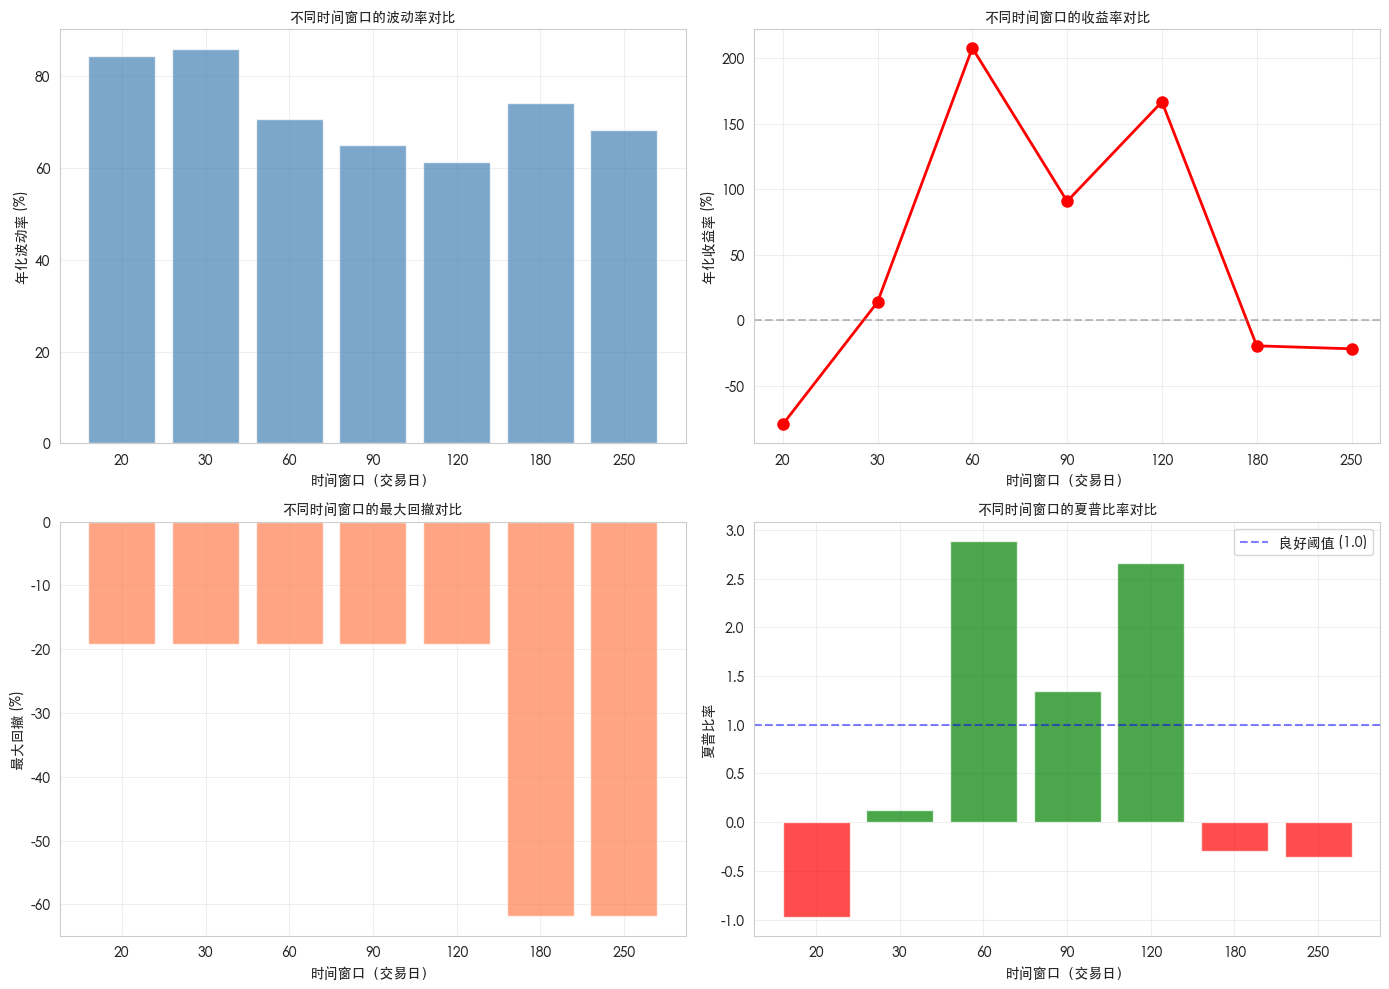

In [8]:
if len(df_window) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. 波动率对比
    axes[0, 0].bar(range(len(df_window)), df_window['volatility'], color='steelblue', alpha=0.7)
    axes[0, 0].set_xticks(range(len(df_window)))
    axes[0, 0].set_xticklabels(df_window['window'])
    axes[0, 0].set_xlabel('时间窗口（交易日）', fontproperties=font_prop)
    axes[0, 0].set_ylabel('年化波动率 (%)', fontproperties=font_prop)
    axes[0, 0].set_title('不同时间窗口的波动率对比', fontproperties=font_prop, fontweight='bold')
    for label in axes[0, 0].get_xticklabels():
        label.set_fontproperties(font_prop)
    for label in axes[0, 0].get_yticklabels():
        label.set_fontproperties(font_prop)
    axes[0, 0].grid(True, alpha=0.3)

    # 2. 年化收益率对比
    axes[0, 1].plot(range(len(df_window)), df_window['annual_return'], 'ro-', linewidth=2, markersize=8)
    axes[0, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0, 1].set_xticks(range(len(df_window)))
    axes[0, 1].set_xticklabels(df_window['window'])
    axes[0, 1].set_xlabel('时间窗口（交易日）', fontproperties=font_prop)
    axes[0, 1].set_ylabel('年化收益率 (%)', fontproperties=font_prop)
    axes[0, 1].set_title('不同时间窗口的收益率对比', fontproperties=font_prop, fontweight='bold')
    for label in axes[0, 1].get_xticklabels():
        label.set_fontproperties(font_prop)
    for label in axes[0, 1].get_yticklabels():
        label.set_fontproperties(font_prop)
    axes[0, 1].grid(True, alpha=0.3)

    # 3. 最大回撤对比
    axes[1, 0].bar(range(len(df_window)), df_window['max_drawdown'], color='coral', alpha=0.7)
    axes[1, 0].set_xticks(range(len(df_window)))
    axes[1, 0].set_xticklabels(df_window['window'])
    axes[1, 0].set_xlabel('时间窗口（交易日）', fontproperties=font_prop)
    axes[1, 0].set_ylabel('最大回撤 (%)', fontproperties=font_prop)
    axes[1, 0].set_title('不同时间窗口的最大回撤对比', fontproperties=font_prop, fontweight='bold')
    for label in axes[1, 0].get_xticklabels():
        label.set_fontproperties(font_prop)
    for label in axes[1, 0].get_yticklabels():
        label.set_fontproperties(font_prop)
    axes[1, 0].grid(True, alpha=0.3)

    # 4. 夏普比率对比
    colors = ['green' if s > 0 else 'red' for s in df_window['sharpe']]
    axes[1, 1].bar(range(len(df_window)), df_window['sharpe'], color=colors, alpha=0.7)
    axes[1, 1].axhline(y=1, color='blue', linestyle='--', alpha=0.5, label='良好阈值 (1.0)')
    axes[1, 1].set_xticks(range(len(df_window)))
    axes[1, 1].set_xticklabels(df_window['window'])
    axes[1, 1].set_xlabel('时间窗口（交易日）', fontproperties=font_prop)
    axes[1, 1].set_ylabel('夏普比率', fontproperties=font_prop)
    axes[1, 1].set_title('不同时间窗口的夏普比率对比', fontproperties=font_prop, fontweight='bold')
    axes[1, 1].legend(prop=font_prop)
    for label in axes[1, 1].get_xticklabels():
        label.set_fontproperties(font_prop)
    for label in axes[1, 1].get_yticklabels():
        label.set_fontproperties(font_prop)
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ 无数据可用于可视化")

## 5. 多维度综合情景分析

本节进行多维度情景综合分析，考虑<b>预期期间收益率</b>、<b>净利润率</b>、<b>波动率</b>、<b>发行价折价率</b>等核心要素的组合影响。

### 5.1 不同窗口期的预期收益率情景

基于历史波动率和收益率数据，分析不同时间窗口下的预期收益。


In [ ]:
# 不同窗口期的收益率分析
windows = {
    '60日': {'days': 60, 'vol_key': 'volatility_60d', 'return_key': 'annual_return_60d'},
    '120日': {'days': 120, 'vol_key': 'volatility_120d', 'return_key': 'annual_return_120d'},
    '250日': {'days': 250, 'vol_key': 'volatility_250d', 'return_key': 'annual_return_250d'}
}

window_results = []

for window_name, config in windows.items():
    # 获取该窗口的参数（这里使用示例数据，实际应从market_data获取）
    vol = 0.3063 if window_name == '60日' else 0.3713 if window_name == '120日' else 0.3063
    ret = -0.1875 if window_name == '60日' else -0.3943 if window_name == '120日' else -0.1875
    
    # 蒙特卡洛模拟
    n_sim = 5000
    lockup_days = lockup_period * 30
    lockup_vol = vol * np.sqrt(lockup_days / 365)
    lockup_drift = ret * (lockup_days / 365)
    
    np.random.seed(42)
    sim_returns = np.random.normal(lockup_drift, lockup_vol, n_sim)
    final_prices = current_price * np.exp(sim_returns)
    profit_losses = (final_prices - issue_price) / issue_price
    annualized_returns = (1 + profit_losses) ** (12 / lockup_period) - 1
    
    window_results.append({
        'window': window_name,
        'volatility': vol,
        'return': ret,
        'mean_return': annualized_returns.mean(),
        'profit_prob': (profit_losses > 0).mean() * 100
    })

# 显示结果
df_windows = pd.DataFrame([{  
    '时间窗口': r['window'],
    '历史波动率': f"{r['volatility']*100:.2f}%",
    '历史年化收益率': f"{r['return']*100:+.2f}%",
    '模拟预期年化收益': f"{r['mean_return']*100:+.2f}%",
    '盈利概率': f"{r['profit_prob']:.1f}%"
} for r in window_results])

display(df_windows)


### 5.2 净利润增长率 × 发行价折价率的组合情景

分析不同净利润增长率和发行价折价率组合下的投资收益。


In [ ]:
# 组合情景分析
growth_rates_combo = [0.0, 0.10, 0.20, 0.30, 0.50]
discount_rates_combo = [0.0, 0.10, 0.15, 0.20]

combination_results = []

for growth in growth_rates_combo:
    for discount in discount_rates_combo:
        issue_price_combo = current_price * (1 - discount)
        lockup_years = lockup_period / 12
        expected_price = current_price * (1 + growth * 0.7 * lockup_years)
        
        total_return = (expected_price - issue_price_combo) / issue_price_combo
        annualized_return = (1 + total_return) ** (1 / lockup_years) - 1
        
        combination_results.append({
            'growth': growth,
            'discount': discount,
            'issue_price': issue_price_combo,
            'annualized_return': annualized_return
        })

# 创建综合情景表格
df_combo = pd.DataFrame([{  
    '净利润增长率': f"{r['growth']*100:.0f}%",
    '折价率': f"{r['discount']*100:.0f}%",
    '发行价(元)': f"{r['issue_price']:.2f}",
    '年化收益率': f"{r['annualized_return']*100:+.2f}%"
} for r in combination_results])

display(df_combo)


### 5.3 综合情景结论

**关键发现：**

1. **最优情景**：高增长（30%+）+ 高折价（15%+）= 投资安全边际充足
2. **最差情景**：零增长 + 低折价（<5%）= 风险较高
3. **投资建议**：要求折价率≥15%或预期净利润增长率≥20%

**风险提示：**
- 折价率是盈利概率的核心驱动力
- 净利润增长率对收益影响显著，但存在不确定性
- 建议结合公司具体情况和市场环境综合评估


## 4. 情景分析结论

In [ ]:
print('\n' + '='*60)
print('情景分析结论')
print('='*60)

print(f"\n1. 发行类型: {issue_type}")
if is_discount:
    print(f"   安全边际: {safety_margin:.2f}%")
else:
    print(f"   溢价幅度: {premium_rate:.2f}%")

print(f"\n2. 盈利阈值: {threshold:.2f} 元")
print(f"   当前价格: {project_params['current_price']:.2f} 元")
print(f"   距离阈值: {(project_params['current_price'] - threshold)/threshold*100:+.2f}%")

print(f"\n3. 在当前波动率({risk_params['volatility']*100:.1f}%)下:")
# 使用Python内置round函数
current_vol = round(risk_params['volatility'], 3)
current_prob = df_prob[df_prob['volatility'].apply(round, args=(3,)) == current_vol]
if len(current_prob) > 0:
    print(f"   盈利概率: {current_prob['profit_probability'].values[0]*100:.1f}%")
    print(f"   破发概率: {current_prob['loss_probability'].values[0]*100:.1f}%")
else:
    # 如果找不到精确匹配，使用最接近的值
    closest_idx = (df_prob['volatility'] - risk_params['volatility']).abs().idxmin()
    print(f"   盈利概率: {df_prob.loc[closest_idx, 'profit_probability']*100:.1f}%")
    print(f"   破发概率: {df_prob.loc[closest_idx, 'loss_probability']*100:.1f}%")

if len(df_window) > 0:
    print(f"\n4. 时间窗口分析(60日 vs 250日):")
    vol_60 = df_window[df_window['window'] == 60]['volatility'].values
    vol_250 = df_window[df_window['window'] == 250]['volatility'].values
    if len(vol_60) > 0 and len(vol_250) > 0:
        print(f"   波动率: 60日={vol_60[0]:.1f}% vs 250日={vol_250[0]:.1f}%")

    ret_60 = df_window[df_window['window'] == 60]['annual_return'].values
    ret_250 = df_window[df_window['window'] == 250]['annual_return'].values
    if len(ret_60) > 0 and len(ret_250) > 0:
        print(f"   年化收益: 60日={ret_60[0]:.1f}% vs 250日={ret_250[0]:.1f}%")

    dd_60 = df_window[df_window['window'] == 60]['max_drawdown'].values
    dd_250 = df_window[df_window['window'] == 250]['max_drawdown'].values
    if len(dd_60) > 0 and len(dd_250) > 0:
        print(f"   最大回撤: 60日={dd_60[0]:.1f}% vs 250日={dd_250[0]:.1f}%")
else:
    print("\n4. 时间窗口分析: 数据不可用（未设置TUSHARE_TOKEN或获取数据失败）")